In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import joblib
import math
import numpy as np
import itertools 
from itertools import product
from collections import Counter
import garpar as gp
import re
import skcriteria as skc
from skcriteria import pipelines
from skcriteria.preprocessing import invert_objectives, weighters, scalers
from skcriteria.preprocessing.increment import AddValueToZero
from skcriteria.madm import similarity, moora, electre
from skcriteria.ranksrev import RankInvariantChecker
from garpar.datasets import make_multisector, RissoLevyStable, RissoNormal, RissoUniform
import warnings

/home/nadia/indicador/lib/python3.10/site-packages/skcriteria/madm.py:30: SKCriteriaDeprecationWarning: 'skcriteria.madm' module is deprecated, use 'skcriteria.agg' instead
  utils.deprecate.warn(deprecation_reason)
/home/nadia/indicador/lib/python3.10/site-packages/skcriteria/agg/similarity.py:27: SKCriteriaDeprecationWarning: The module 'skcriteria.agg.similarity' is deprecated since v0.9 and will be removed in v1.0. Please use 'skcriteria.agg.topsis' instead.
  deprecate.warn(


In [2]:
# --- 1. Definición de Nombres (Tickers) ---
nombres_acciones = [
    "CRES", "CADO", "GARO", "INVJ",                                     # AGRO
    "CVH", "TECO2", "AUSO", "BOLT", "CTIO", "DYCA", "GAMI", "GCLA",     # COME (1-8)
    "IRSA", "OEST", "PATA", "POLL", "TGLT",                             # COME (9-13)
    "CEPU", "COME", "EDN", "PAMP", "TGNO4", "TGSU2", "TRAN", "YPFD",    # ENE (1-8)
    "CAPX", "CARC", "CECO2", "CGPA2", "DGCU2", "GBAN", "METR", "MTR",   # ENE (9-16)
    "BBAR", "BMA", "BYMA", "GGAL", "SUPV", "VALO", "BHIP", "BPAT",      # FIN
    "CELU", "GRIM", "HAVA", "INTR", "LEDE", "MOLA", "MOLI", "MORI",     # MOA (1-8)
    "RICH", "SAMI", "SEMI",                                             # MOA (9-11)
    "ALUA", "HARG", "LOMA", "MIRG", "TXAR", "AGRO", "DOME", "FERR",     # MOI (1-8)
    "FIPL", "LONG", "RIGO"                                              # MOI (9-11)
]

In [3]:
# --- 1. Configuración de Parámetros Fijos ---
NUM_ITERACIONES = 200
DIAS_SIMULACION = 40
VENTANAS_A_PROBAR = [3, 5, 7] 

# --- 2. Precios Iniciales (Lista Completa) ---
PRECIOS_INICIALES_TOTAL = [
    1515.00, 475.50, 200.00, 325.00,                      # AGRO (4)
    7000.00, 2490.00, 2725.00, 44.85, 1880.00, 840.00,    # COME (1-6)
    235.75, 2750.00, 2015.00, 710.00, 1300.00, 300.00,    # COME (7-12)
    20.90,                                                # COME (13)
    1655.00, 131.25, 1950.00, 4130.00, 3345.00, 7840.00,  # ENE (1-6)
    2630.00, 45600.00, 5150.00, 29.95, 407.00, 2420.00,   # ENE (7-12)
    1590.00, 1945.00, 2160.00, 2600.00,                   # ENE (13-16)
    7140.00, 9420.00, 206.75, 6870.00, 2830.00, 365.50,   # FIN (1-6)
    419.00, 2265.00,                                      # FIN (7-8)
    311.00, 2150.00, 5900.00, 400.00, 1010.00, 24450.00,  # MOA (1-6)
    3060.00, 224.00, 1500.00, 636.00, 25.55,              # MOA (7-11)
    787.00, 1550.00, 3195.00, 23500.00, 696.00, 49.60,    # MOI (1-6)
    70.00, 25.85, 240.00, 27.00, 670.00                   # MOI (7-11)
]
# --- DEFINICIÓN DE PARÁMETROS INDEPENDIENTES ---

# Parámetros Lévy-Stable con colas más pesadas (Alpha reducido)

params_AGRO = {"alpha": 1.691787, "beta": -0.29406, "mu": -0.00044311, "sigma": 0.01348009, "entropy": 0.30} # Alpha anterior: 1.735319
params_COME = {"alpha": 1.7859876, "beta": 0.097854, "mu": -0.00019964, "sigma": 0.01222466, "entropy": 0.30} # Alpha anterior: 1.899862
params_ENE  = {"alpha": 1.801308, "beta": -0.99996, "mu": -7.3322e-05, "sigma": 0.01895143, "entropy": 0.30} # Alpha anterior: 1.945898
params_FIN  = {"alpha": 1.752057, "beta": 0.154295, "mu": 0.00055458,  "sigma": 0.02040389, "entropy": 0.40} # Alpha anterior: 1.857841
params_MOA  = {"alpha": 1.599809, "beta": -0.29668, "mu": -0.00229919, "sigma": 0.01339190, "entropy": 0.40} # Alpha anterior: 1.633121
params_MOI  = {"alpha": 1.747378, "beta": -0.65803, "mu": -0.00149594, "sigma": 0.01482495, "entropy": 0.40} # Alpha anterior: 1.841531


# AJUSTE AUTOMÁTICO DE STOCKS_TOTALES
STOCKS_TOTALES = len(PRECIOS_INICIALES_TOTAL) # Esto ahora será 63

# --- 3. Definición de Parámetros (Asegurando 63 entradas) ---
# Usamos multiplicadores para no equivocarnos en la cuenta
parametros_sectores_base = (
    [params_AGRO] * 4 + 
    [params_COME] * 13 + 
    [params_ENE] * 16 + 
    [params_FIN] * 8 + 
    [params_MOA] * 11 + 
    [params_MOI] * 11
)

# Verificación de seguridad
if len(parametros_sectores_base) != STOCKS_TOTALES:
    print(f"ERROR: Tienes {len(parametros_sectores_base)} parámetros pero {STOCKS_TOTALES} precios.")

# --- 4. BUCLE DE SIMULACIÓN ---
resultados_por_ventana = {ventana: [] for ventana in VENTANAS_A_PROBAR}

for VENTANA in VENTANAS_A_PROBAR:
    print(f"Iniciando {NUM_ITERACIONES} simulaciones para Ventana: {VENTANA} días...")
    
    for i in range(NUM_ITERACIONES):
        random_seed_base = i * 10000 
        distribuciones_para_corrida = []
        
        for j, params in enumerate(parametros_sectores_base):
            semilla_sector = random_seed_base + (j * 100)
            params_corrida = params.copy() 
            params_corrida['random_state'] = semilla_sector
            # Se asume que RissoLevyStable está importada correctamente
            distribuciones_para_corrida.append(RissoLevyStable(**params_corrida))

        # SIMULACIÓN DEL MERCADO
        stocksset = make_multisector(
            *distribuciones_para_corrida,
            stocks=STOCKS_TOTALES,  
            days=DIAS_SIMULACION,
            window_size=VENTANA,
            price=PRECIOS_INICIALES_TOTAL 
        )
        
        df_simulacion = stocksset._prices_df 
        resultados_por_ventana[VENTANA].append(df_simulacion)
    
print("\n--- ¡Generación de Simulaciones Finalizada! ---")

Iniciando 200 simulaciones para Ventana: 3 días...
Iniciando 200 simulaciones para Ventana: 5 días...
Iniciando 200 simulaciones para Ventana: 7 días...

--- ¡Generación de Simulaciones Finalizada! ---


In [4]:
# --- 5. Definición de Nombres de Acciones (Fuera del bucle) ---
nombres_acciones = [
    "CRES", "CADO", "GARO", "INVJ",                                     # AGRO
    "CVH", "TECO2", "AUSO", "BOLT", "CTIO", "DYCA", "GAMI", "GCLA",     # COME (1-8)
    "IRSA", "OEST", "PATA", "POLL", "TGLT",                             # COME (9-13)
    "CEPU", "COME", "EDN", "PAMP", "TGNO4", "TGSU2", "TRAN", "YPFD",    # ENE (1-8)
    "CAPX", "CARC", "CECO2", "CGPA2", "DGCU2", "GBAN", "METR", "MTR",   # ENE (9-16)
    "BBAR", "BMA", "BYMA", "GGAL", "SUPV", "VALO", "BHIP", "BPAT",      # FIN
    "CELU", "GRIM", "HAVA", "INTR", "LEDE", "MOLA", "MOLI", "MORI",     # MOA (1-8)
    "RICH", "SAMI", "SEMI",                                             # MOA (9-11)
    "ALUA", "HARG", "LOMA", "MIRG", "TXAR", "AGRO", "DOME", "FERR",     # MOI (1-8)
    "FIPL", "LONG", "RIGO"                                              # MOI (9-11)
]

# --- 6. Ensamblado: Asignación de Nombres a los DataFrames Resultantes ---
# Recorremos el diccionario generado en el paso 4 y renombramos las columnas
for ventana in VENTANAS_A_PROBAR:
    for df in resultados_por_ventana[ventana]:
        # Asignamos los nombres directamente a las columnas del DataFrame
        df.columns = nombres_acciones

print("--- Nombres de acciones integrados correctamente en todos los DataFrames ---")

--- Nombres de acciones integrados correctamente en todos los DataFrames ---


In [5]:
# --- 0. CONFIGURACIÓN INICIAL ---
# Suprimir el warning común de garpar/pypfopt sobre matrices no positivas
warnings.filterwarnings('ignore', category=UserWarning, message='The covariance matrix is non positive semidefinite. Amending eigenvalues.')
warnings.filterwarnings('ignore', category=UserWarning, message="No risk_free_rate specified, coercing it")
# ⚠️ DEFINICIÓN DE LOS OPTIMIZADORES A PROBAR (Asumida)
optimizadores_a_probar = {
   "Sharpe": gp.optimize.mean_variance.MVOptimizer(model='max_sharpe'),
    "Markowitz s.a ret 0.001": gp.optimize.mean_variance.Markowitz(target_return=0.001),
    "Markowitz s.a ret 0.01": gp.optimize.mean_variance.Markowitz(target_return=0.01),
    "Markowitz s.a. riesgo 0.20 ": gp.optimize.mean_variance.Markowitz(target_risk=0.20),
    "Markowitz s.a. riesgo 0.25 ": gp.optimize.mean_variance.Markowitz(target_risk=0.25),
    "Markowitz s.a. riesgo 0.30 ": gp.optimize.mean_variance.Markowitz(target_risk=0.30),


}

rows = []

print("--- INICIO DEL PROCESAMIENTO DE MÉTRICAS (Usando StocksSet) ---")

# --- 1. BUCLE DE PROCESAMIENTO SOBRE LOS RESULTADOS GUARDADOS ---

for VENTANA, lista_simulaciones in resultados_por_ventana.items():
    
    for i, df_corrida in enumerate(lista_simulaciones):
        
        corrida_id = i + 1
        stocks_number_base = len(df_corrida.columns)

        # 💡 MEJORA DE ROBUSTEZ: Intentar crear el StocksSet primero
        stocksset_corrida = None
        try:
            stocksset_corrida = gp.StocksSet.from_prices(df_corrida, window_size=VENTANA)
        except Exception as e:
            # Si el StocksSet falla (ej: datos malformados), registra el fallo para TODOS los modelos
            print(f"⚠️ Error al crear StocksSet (Corrida {corrida_id}, Ventana {VENTANA}): {e}. Saltando modelos.")
            
            for opt_name in optimizadores_a_probar.keys():
                rows.append({
                    "Ventana": VENTANA,
                    "Corrida": corrida_id,
                    "Modelo_Opt": opt_name,
                    "stocks_number": stocks_number_base, 
                    "Cross_Entropy": np.nan,
                    "Zheng_Entropy": np.nan,
                    "Div_Ratio": np.nan,
                    "CV_MC": np.nan,
                    "PDI": np.nan
                })
            continue # Pasa a la siguiente corrida
        
        # 2. ITERACIÓN SOBRE LOS MODELOS DE OPTIMIZACIÓN
        for opt_name, optimizador in optimizadores_a_probar.items():
            
            try:
                # 3. OPTIMIZACIÓN + PRUNING
                mopt = optimizador.optimize(stocksset_corrida).weights_prune()
                
                # 4. CÁLCULO DE MÉTRICAS (EXITOSO)
                metricas = {
                    "stocks_number": len(mopt.stocks),
                    "Cross_Entropy": mopt.div.cross_entropy(),
                    "Zheng_Entropy": mopt.div.zheng_entropy(),
                    "Div_Ratio": mopt.div.ratio(),
                    "CV_MC": (mopt.div.mrc() * mopt.weights).std() / (mopt.div.mrc() * mopt.weights).mean(),
                    "PDI": mopt.div.pdi(n_components=3, random_state=100)
                }

                # 5. GUARDAR RESULTADO EXITOSO
                rows.append({
                    "Ventana": VENTANA,
                    "Corrida": corrida_id,
                    "Modelo_Opt": opt_name, 
                    **metricas
                })

            except Exception as e:
                #  Garantizar que la fila de identificadores se guarde
                rows.append({
                    "Ventana": VENTANA,
                    "Corrida": corrida_id,
                    "Modelo_Opt": opt_name,
                    "stocks_number": stocks_number_base, 
                    "Cross_Entropy": np.nan,
                    "Zheng_Entropy": np.nan,
                    "Div_Ratio": np.nan,
                    "CV_MC": np.nan,
                    "PDI": np.nan
                })
            
# --- 2. CREACIÓN DEL DATAFRAME FINAL ---

df_metricas_simulacion = pd.DataFrame(rows)

# Esta línea ahora es segura, ya que 'rows' garantiza las claves de índice
df_metricas_simulacion = df_metricas_simulacion.set_index(["Ventana", "Corrida", "Modelo_Opt"])

print("\n--- ANÁLISIS COMPLETADO ---")
print(f"Total de resultados guardados: {len(df_metricas_simulacion)} filas.")
print(df_metricas_simulacion.head(9))


--- INICIO DEL PROCESAMIENTO DE MÉTRICAS (Usando StocksSet) ---


/home/nadia/indicador/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/expected_returns.py:32: UserWarning: Som

ERROR in LDL_factor: Error in KKT matrix LDL factorization when computing the nonzero elements. The problem seems to be non-convex
ERROR in osqp_setup: KKT matrix factorization.
The problem seems to be non-convex.
ERROR in LDL_factor: Error in KKT matrix LDL factorization when computing the nonzero elements. The problem seems to be non-convex
ERROR in osqp_setup: KKT matrix factorization.
The problem seems to be non-convex.
ERROR in LDL_factor: Error in KKT matrix LDL factorization when computing the nonzero elements. The problem seems to be non-convex
ERROR in osqp_setup: KKT matrix factorization.
The problem seems to be non-convex.


/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
/home/nadi

ERROR in LDL_factor: Error in KKT matrix LDL factorization when computing the nonzero elements. The problem seems to be non-convex
ERROR in osqp_setup: KKT matrix factorization.
The problem seems to be non-convex.
ERROR in LDL_factor: Error in KKT matrix LDL factorization when computing the nonzero elements. The problem seems to be non-convex
ERROR in osqp_setup: KKT matrix factorization.
The problem seems to be non-convex.
ERROR in LDL_factor: Error in KKT matrix LDL factorization when computing the nonzero elements. The problem seems to be non-convex
ERROR in osqp_setup: KKT matrix factorization.
The problem seems to be non-convex.


/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/risk_models.py:89: UserWarning: Could not fix matrix. Please try a different risk model.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/risk_models.py:89: UserWarning: Could not fix matrix. Please try a different risk model.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/risk_models.py:89: UserWarning: Could not fix matrix. Please try a different risk model.
  warnings.warn(
/home/nadi

ERROR in LDL_factor: Error in KKT matrix LDL factorization when computing the nonzero elements. The problem seems to be non-convex
ERROR in osqp_setup: KKT matrix factorization.
The problem seems to be non-convex.
ERROR in LDL_factor: Error in KKT matrix LDL factorization when computing the nonzero elements. The problem seems to be non-convex
ERROR in osqp_setup: KKT matrix factorization.
The problem seems to be non-convex.
ERROR in LDL_factor: Error in KKT matrix LDL factorization when computing the nonzero elements. The problem seems to be non-convex
ERROR in osqp_setup: KKT matrix factorization.
The problem seems to be non-convex.


/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
/home/nadi


--- ANÁLISIS COMPLETADO ---
Total de resultados guardados: 3600 filas.
                                             stocks_number  Cross_Entropy  \
Ventana Corrida Modelo_Opt                                                  
3       1       Sharpe                                  63            NaN   
                Markowitz s.a ret 0.001                 35       0.475493   
                Markowitz s.a ret 0.01                  35       0.475493   
                Markowitz s.a. riesgo 0.20               5       1.035164   
                Markowitz s.a. riesgo 0.25               4       0.809600   
                Markowitz s.a. riesgo 0.30               3       0.159287   
        2       Sharpe                                  36       0.538833   
                Markowitz s.a ret 0.001                 63            NaN   
                Markowitz s.a ret 0.01                  63            NaN   

                                             Zheng_Entropy  Div_Ratio  \
Ventana

In [6]:
df_metricas_simulacion[(df_metricas_simulacion.index.get_level_values('Ventana') == 3) &
    (df_metricas_simulacion.index.get_level_values('Corrida') ==10)]

stocks_number  Cross_Entropy  \
Ventana Corrida Modelo_Opt                                                  
3       10      Sharpe                                  63            NaN   
                Markowitz s.a ret 0.001                 63            NaN   
                Markowitz s.a ret 0.01                  63            NaN   
                Markowitz s.a. riesgo 0.20              15       3.058633   
                Markowitz s.a. riesgo 0.25              18       8.433676   
                Markowitz s.a. riesgo 0.30               9       5.521307   

                                             Zheng_Entropy  Div_Ratio  \
Ventana Corrida Modelo_Opt                                              
3       10      Sharpe                                 NaN        NaN   
                Markowitz s.a ret 0.001                NaN        NaN   
                Markowitz s.a ret 0.01                 NaN        NaN   
                Markowitz s.a. riesgo 0.20        1.981117   0.212739   
                Markowitz s.a. riesgo 0.25        1.780739   0.178279   
                Markowitz s.a. riesgo 0.30        1.600533   0.155458   

                                                CV_MC       PDI  
Ventana Corrida Modelo_Opt                                       
3       10      Sharpe                            NaN       NaN  
                Markowitz s.a ret 0.001           NaN       NaN  
                Markowitz s.a ret 0.01            NaN       NaN  
                Markowitz s.a. riesgo 0.20   3.991667  1.562679  
                Markowitz s.a. riesgo 0.25   4.295982  1.476076  
                Markowitz s.a. riesgo 0.30   2.998071  1.762553

In [7]:
df_metricas_simulacion[(df_metricas_simulacion.index.get_level_values('Ventana') == 3) &
    (df_metricas_simulacion.index.get_level_values('Corrida') ==12)].droplevel('Ventana').droplevel('Corrida')

,stocks_number,Cross_Entropy,Zheng_Entropy,Div_Ratio,CV_MC,PDI
Modelo_Opt,,,,,,
Sharpe,34,0.491776,3.188899,4.460274,2.503318,0.969818
Markowitz s.a ret 0.001,36,0.425888,3.259639,5.864328,0.826064,0.478150
Markowitz s.a ret 0.01,36,0.425888,3.259639,5.864328,0.826064,0.478150
Markowitz s.a. riesgo 0.20,8,2.627976,1.490667,0.148877,3.156197,1.239264
Markowitz s.a. riesgo 0.25,6,0.564074,1.301414,0.121580,2.658439,1.398735
Markowitz s.a. riesgo 0.30,6,0.803555,1.110426,0.103209,2.551234,1.398735


In [8]:
#Eliminar corridas con NaN ===
# =========================================================================

# 1. Identificar el nivel del índice que representa la "corrida"
LEVEL_CORRIDA = 'Corrida' 

# 2. Inicializar una lista para guardar las corridas (índices) que deben eliminarse
corridas_a_eliminar = set()

# 3. Iterar sobre las corridas (grupos) para verificar NaNs
for corrida_id, group_df in df_metricas_simulacion.groupby(level=LEVEL_CORRIDA):
    
    # 4. Verificar si existe AL MENOS UN NaN en CUALQUIERA de las filas
    # .isnull() crea un DF booleano, .any(axis=None) verifica si hay True en todo el grupo.
    if group_df.isnull().any().any(): 
        # Si se encuentra un NaN, se añade el ID de la corrida a la lista de eliminación
        corridas_a_eliminar.add(corrida_id)

# 5. Filtrar el DataFrame original, excluyendo las corridas identificadas
# Creamos una máscara booleana: True para las corridas que NO están en la lista
mascara_mantener = ~df_metricas_simulacion.index.get_level_values(LEVEL_CORRIDA).isin(corridas_a_eliminar)

# Aplicar la máscara al DataFrame
df_metricas_limpio = df_metricas_simulacion[mascara_mantener]


In [9]:
df_metricas_limpio[df_metricas_limpio.index.get_level_values('Ventana') == 3].describe()

,stocks_number,Cross_Entropy,Zheng_Entropy,Div_Ratio,CV_MC,PDI
count,666.000000,666.000000,666.000000,6.660000e+02,6.660000e+02,666.000000
mean,23.045045,1.515011,2.376611,1.030581e+05,1.654725e+04,0.952693
std,14.655474,1.842870,0.899482,1.259311e+06,2.367191e+05,0.551452
min,3.000000,0.046021,0.390847,7.322448e-02,5.521891e-01,0.082031
25%,9.000000,0.412777,1.519575,1.498394e-01,9.113568e-01,0.478150
50%,27.000000,0.564986,2.562436,4.694427e-01,2.063826e+00,0.933545
75%,35.000000,2.038271,3.231303,2.543820e+00,3.522170e+00,1.395161
max,63.000000,10.268727,3.449954,1.911154e+07,4.561648e+06,2.538946


In [10]:
# =========================================================================
# === Definiciones 
# =========================================================================

# 1. Definición de Objetivos (idéntica a tu código)
objectives = [
    max, # 'stocks_number'
    min, # 'Cross_Entropy'
    max, # 'Zheng_Entropy'
    max, # 'Div_Ratio'
    min, # 'CV_MC'
    max, # 'PDI'
]

# 2. Identificar el nivel 'Ventana' que quieres filtrar (parece ser '3')
VENTANA_FILTRO = 3
LEVEL_VENTANA = 'Ventana'
LEVEL_CORRIDA = 'Corrida'

# 3. Filtrar por Ventana = 3 (esto simplifica la iteración)
df_ventana_3 = df_metricas_limpio[
    df_metricas_limpio.index.get_level_values(LEVEL_VENTANA) == VENTANA_FILTRO].copy()

# === PASO CRÍTICO: OBTENER LOS IDs DE CORRIDA REALES ===
# =========================================================================
# Obtenemos la lista ÚNICA de los identifi}cadores de corrida que existen 
corridas_existentes_v3 = df_ventana_3.index.get_level_values('Corrida').unique().tolist()
corridas_existentes_v3;


In [11]:
len(corridas_existentes_v3)


111

In [12]:
# Diccionario para almacenar las Matrices de Decisión generadas
matrices_decision = {}

# Iteramos sobre los IDs de corrida REALES (ej: '10', '11'...)
for el_corrida_id in corridas_existentes_v3:

    # 1. Filtramos el DataFrame de MÉTRICAS para la corrida actual
    df_filtrado = df_ventana_3[df_ventana_3.index.get_level_values('Corrida') == el_corrida_id].droplevel(['Ventana', 'Corrida'])
    
    # 2. ACCESO AL DATAFRAME ORIGINAL DE PESOS (Variable nueva solicitada)

    # === Extracción de elementos para skcriteria ===
    data = df_filtrado.to_numpy() 
    alternatives = df_filtrado.index 
    criteria = df_filtrado.columns 
    
    # === Generar la Matriz de Decisión ===
    dm = skc.mkdm(
        data, 
        objectives=objectives,
        alternatives=alternatives, 
        criteria=criteria
    )
    
    # Guardar la DM
    matrices_decision[el_corrida_id] = dm



In [13]:
# 1. Definición del Pipeline
pipe_igual_vector = pipelines.mkpipe(
    # CAMBIO 1: Se agrega AddValueToZero al inicio para evitar divisiones por cero posteriores
    AddValueToZero(target="matrix", value=1e-10), 
    invert_objectives.NegateMinimize(),
    scalers.VectorScaler(target="matrix"),
    weighters.EqualWeighter(),
    similarity.TOPSIS(), 
)

# VARIABLE NUEVA: Lista para acumular los resultados de similaridad
resultados_similaridad = []

for el_corrida_id in corridas_existentes_v3:
    
    # 1. Recuperamos la DM del diccionario generado anteriormente
    dm = matrices_decision[el_corrida_id]
    
    # CAMBIO 3: Bloque try-except para capturar si una matriz es totalmente constante
    try:
        # 2. Ejecución del pipeline
        result_igual_vector = pipe_igual_vector.evaluate(dm)
        
        # === CORRECCIÓN DEL ERROR Y CAMBIO DE NOMBRE ===
        # Convertimos el array de numpy (result_igual_vector.e_.similarity) a DataFrame
        df_similaridad_parcial = pd.DataFrame(
            [result_igual_vector.e_.similarity], 
            columns=dm.alternatives, 
            index=[el_corrida_id]
        )
        
        # 3. Guardamos en la lista para concatenar después
        resultados_similaridad.append(df_similaridad_parcial)
        
    except Exception as e:
        # CAMBIO 4: Manejo de errores para evitar que el bucle se detenga por datos inválidos
        print(f"Error en la corrida {el_corrida_id}: {e}")
        continue

# 4. CREACIÓN DEL DATAFRAME FINAL
if resultados_similaridad:
    df_similaridad_total_v3 = pd.concat(resultados_similaridad)
    df_similaridad_total_v3.index.name = 'Corrida'
else:
    df_similaridad_total_v3 = pd.DataFrame()

# Visualizar resultado consolidado de similaridad
df_similaridad_total_v3

,Sharpe,Markowitz s.a ret 0.001,Markowitz s.a ret 0.01,Markowitz s.a. riesgo 0.20,Markowitz s.a. riesgo 0.25,Markowitz s.a. riesgo 0.30
Corrida,,,,,,
4,0.648860,0.711574,0.711574,0.548783,0.302687,0.466815
5,0.522823,0.701011,0.701011,0.311654,0.416383,0.265161
7,0.553882,0.732843,0.732843,0.468891,0.315032,0.522914
8,0.555083,0.657747,0.657747,0.395071,0.346112,0.566195
9,0.541033,0.670531,0.670531,0.408865,0.320259,0.329319
...,...,...,...,...,...,...
195,0.597412,0.757151,0.757151,0.468593,0.401950,0.321137
196,0.570341,0.635667,0.635667,0.460184,0.272727,0.557711
197,0.423079,0.739502,0.739502,0.454359,0.279420,0.468519


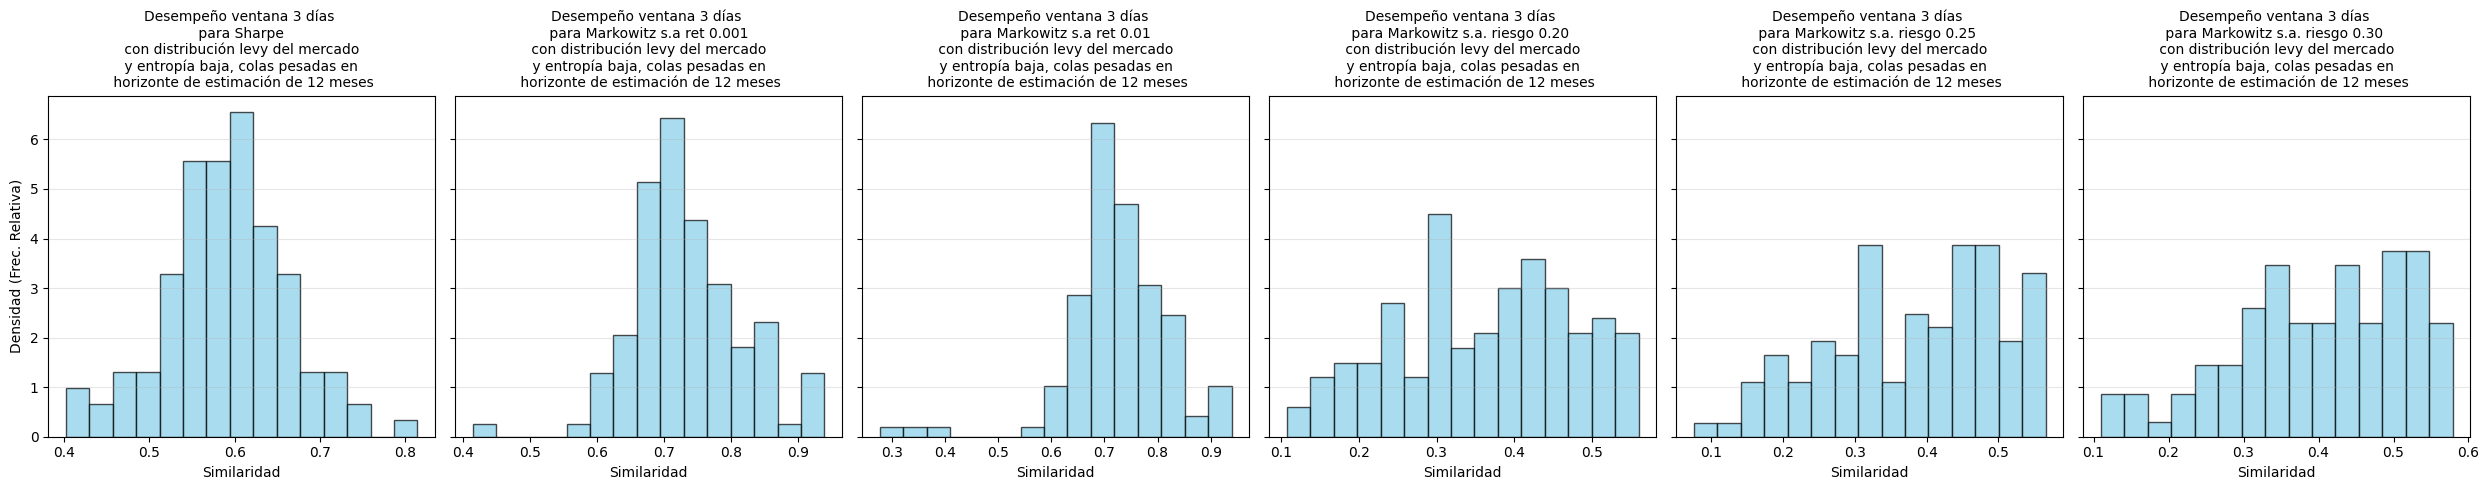

In [14]:
# 1. Configuración de la grilla (Forzada a 1 fila de 5 columnas)
modelos = df_similaridad_total_v3.columns
n_modelos = len(modelos)
n_cols = 6  # Cambiado a 5 para que entren todos en una fila
n_rows = 1  # Forzado a 1 renglón

# 2. Crear la figura y los subplots
# He aumentado el ancho (25) para que los 5 gráficos tengan espacio
fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, 5), sharey=True, sharex=False)

# 3. Bucle para generar cada histograma
for i, modelo in enumerate(modelos):
    # Si solo hay una fila, axes puede no ser una matriz, lo tratamos con cuidado
    ax = axes[i] if n_modelos > 1 else axes
    
    # Generar el histograma con densidad
    ax.hist(df_similaridad_total_v3[modelo], bins=15, color='skyblue', 
            edgecolor='black', alpha=0.7, density=True)
    
    # Configuración del título
    ax.set_title(f'Desempeño ventana 3 días \n para {modelo} \n con distribución levy del mercado \n y entropía baja, colas pesadas en \n horizonte de estimación de 12 meses', fontsize=10)

    ax.set_xlabel('Similaridad')
    # Solo ponemos el label del eje Y en el primero para no saturar
    if i == 0:
        ax.set_ylabel('Densidad (Frec. Relativa)')
        
    ax.grid(axis='y', alpha=0.3)

# 4. Limpiar subplots vacíos (en caso de que haya menos de 5 modelos)
if n_modelos < n_cols:
    for j in range(i + 1, n_cols):
        fig.delaxes(axes[j])

# Ajustar espaciado
plt.tight_layout()
fig.savefig("imgs_simu/5_Ci_hist_v3_mdocp_be", dpi=300, bbox_inches='tight')

In [15]:
# =========================================================================
# === Definiciones 
# =========================================================================

# 1. Definición de Objetivos (idéntica a tu código)
objectives = [
    max, # 'stocks_number'
    min, # 'Cross_Entropy'
    max, # 'Zheng_Entropy'
    max, # 'Div_Ratio'
    min, # 'CV_MC'
    max, # 'PDI'
]

# 2. Identificar el nivel 'Ventana' que quieres filtrar (parece ser '3')
VENTANA_FILTRO = 5
LEVEL_VENTANA = 'Ventana'
LEVEL_CORRIDA = 'Corrida'

# 3. Filtrar por Ventana = 3 (esto simplifica la iteración)
df_ventana_5 = df_metricas_limpio[
    df_metricas_limpio.index.get_level_values(LEVEL_VENTANA) == VENTANA_FILTRO].copy()

# === PASO CRÍTICO: OBTENER LOS IDs DE CORRIDA REALES ===
# =========================================================================
# Obtenemos la lista ÚNICA de los identifi}cadores de corrida que existen 
corridas_existentes_v5 = df_ventana_5.index.get_level_values('Corrida').unique().tolist()
corridas_existentes_v5;


In [16]:
len(corridas_existentes_v5)

111

In [17]:
# Diccionario para almacenar las Matrices de Decisión generadas
matrices_decision = {}

# Iteramos sobre los IDs de corrida REALES (ej: '10', '11'...)
for el_corrida_id in corridas_existentes_v5:

    # 1. Filtramos el DataFrame de MÉTRICAS para la corrida actual
    df_filtrado = df_ventana_5[df_ventana_5.index.get_level_values('Corrida') == el_corrida_id].droplevel(['Ventana', 'Corrida'])
    
    # 2. ACCESO AL DATAFRAME ORIGINAL DE PESOS (Variable nueva solicitada)

    # === Extracción de elementos para skcriteria ===
    data = df_filtrado.to_numpy() 
    alternatives = df_filtrado.index 
    criteria = df_filtrado.columns 
    
    # === Generar la Matriz de Decisión ===
    dm = skc.mkdm(
        data, 
        objectives=objectives,
        alternatives=alternatives, 
        criteria=criteria
    )
    
    # Guardar la DM
    matrices_decision[el_corrida_id] = dm


In [18]:
# 1. Definición del Pipeline
pipe_igual_vector = pipelines.mkpipe(
    AddValueToZero(target="matrix", value=1e-10), 
    invert_objectives.NegateMinimize(),
    scalers.VectorScaler(target="matrix"),
    weighters.EqualWeighter(),
    similarity.TOPSIS(),
)
# VARIABLE NUEVA: Lista para acumular los resultados de similaridad
resultados_similaridad = []

for el_corrida_id in corridas_existentes_v5:
    
    # 1. Recuperamos la DM del diccionario generado anteriormente
    dm = matrices_decision[el_corrida_id]
    
   
    # CAMBIO 3: Bloque try-except para capturar si una matriz es totalmente constante
    try:
        # 2. Ejecución del pipeline
        result_igual_vector = pipe_igual_vector.evaluate(dm)
        
        # === CORRECCIÓN DEL ERROR Y CAMBIO DE NOMBRE ===
        # Convertimos el array de numpy (result_igual_vector.e_.similarity) a DataFrame
        df_similaridad_parcial = pd.DataFrame(
            [result_igual_vector.e_.similarity], 
            columns=dm.alternatives, 
            index=[el_corrida_id]
        )
        
        # 3. Guardamos en la lista para concatenar después
        resultados_similaridad.append(df_similaridad_parcial)
        
    except Exception as e:
        # CAMBIO 4: Manejo de errores para evitar que el bucle se detenga por datos inválidos
        print(f"Error en la corrida {el_corrida_id}: {e}")
        continue

# 4. CREACIÓN DEL DATAFRAME FINAL
if resultados_similaridad:
    df_similaridad_total_v5 = pd.concat(resultados_similaridad)
    df_similaridad_total_v5.index.name = 'Corrida'
else:
    df_similaridad_total_v5 = pd.DataFrame()

# Visualizar resultado consolidado de similaridad
df_similaridad_total_v5

,Sharpe,Markowitz s.a ret 0.001,Markowitz s.a ret 0.01,Markowitz s.a. riesgo 0.20,Markowitz s.a. riesgo 0.25,Markowitz s.a. riesgo 0.30
Corrida,,,,,,
4,0.636009,0.709093,0.709093,0.445779,0.402039,0.343019
5,0.736406,0.917381,0.917381,0.329417,0.142208,0.507238
7,0.525814,0.658381,0.658381,0.290495,0.432453,0.508992
8,0.624806,0.728216,0.728216,0.256865,0.527393,0.498216
9,0.532451,0.666445,0.666445,0.267515,0.375060,0.371238
...,...,...,...,...,...,...
195,0.542826,0.619715,0.619715,0.265543,0.468173,0.548855
196,0.635961,0.702716,0.702716,0.476347,0.499956,0.293677
197,0.542781,0.742391,0.742391,0.204095,0.227709,0.284956


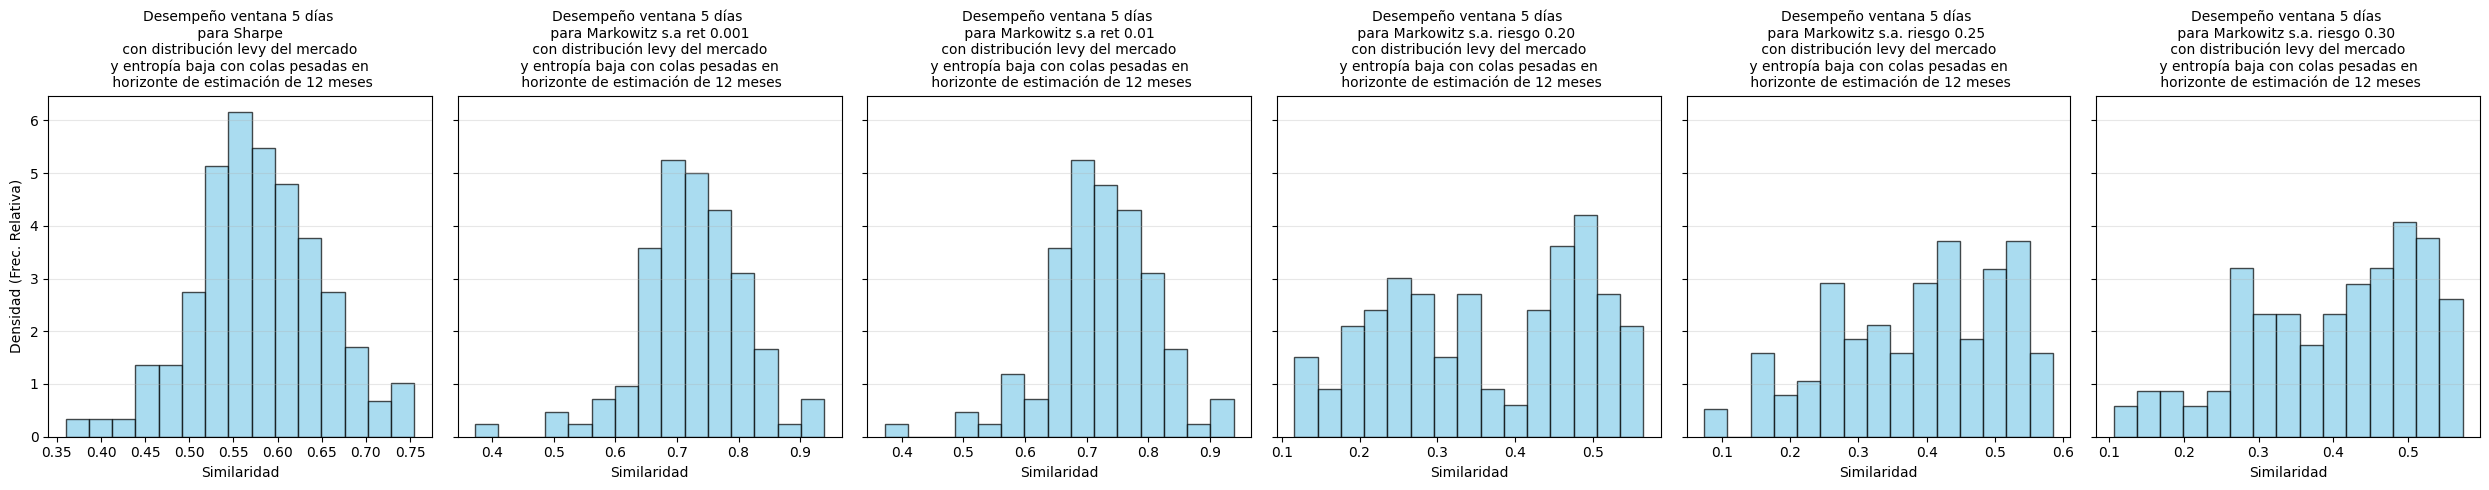

In [19]:
# 1. Configuración de la grilla (Forzada a 1 fila de 5 columnas)
modelos = df_similaridad_total_v5.columns
n_modelos = len(modelos)
n_cols = 6  # Cambiado a 5 para que entren todos en una fila
n_rows = 1  # Forzado a 1 renglón

# 2. Crear la figura y los subplots
# He aumentado el ancho (25) para que los 5 gráficos tengan espacio
fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, 5), sharey=True, sharex=False)

# 3. Bucle para generar cada histograma
for i, modelo in enumerate(modelos):
    # Si solo hay una fila, axes puede no ser una matriz, lo tratamos con cuidado
    ax = axes[i] if n_modelos > 1 else axes
    
    # Generar el histograma con densidad
    ax.hist(df_similaridad_total_v5[modelo], bins=15, color='skyblue', 
            edgecolor='black', alpha=0.7, density=True)
    
    # Configuración del título
    ax.set_title(f'Desempeño ventana 5 días \n para {modelo} \n con distribución levy del mercado \n y entropía baja con colas pesadas en \n horizonte de estimación de 12 meses', fontsize=10)

    ax.set_xlabel('Similaridad')
    # Solo ponemos el label del eje Y en el primero para no saturar
    if i == 0:
        ax.set_ylabel('Densidad (Frec. Relativa)')
        
    ax.grid(axis='y', alpha=0.3)

# 4. Limpiar subplots vacíos (en caso de que haya menos de 5 modelos)
if n_modelos < n_cols:
    for j in range(i + 1, n_cols):
        fig.delaxes(axes[j])

# Ajustar espaciado
plt.tight_layout()
fig.savefig("imgs_simu/5_Ci_hist_v5_mdocp_be", dpi=300, bbox_inches='tight')

In [20]:
# =========================================================================
# === Definiciones 
# =========================================================================

# 1. Definición de Objetivos (idéntica a tu código)
objectives = [
    max, # 'stocks_number'
    min, # 'Cross_Entropy'
    max, # 'Zheng_Entropy'
    max, # 'Div_Ratio'
    min, # 'CV_MC'
    max, # 'PDI'
]

# 2. Identificar el nivel 'Ventana' que quieres filtrar (parece ser '3')
VENTANA_FILTRO = 7
LEVEL_VENTANA = 'Ventana'
LEVEL_CORRIDA = 'Corrida'

# 3. Filtrar por Ventana = 3 (esto simplifica la iteración)
df_ventana_7 = df_metricas_limpio[
    df_metricas_limpio.index.get_level_values(LEVEL_VENTANA) == VENTANA_FILTRO].copy()

# === PASO CRÍTICO: OBTENER LOS IDs DE CORRIDA REALES ===
# =========================================================================
# Obtenemos la lista ÚNICA de los identifi}cadores de corrida que existen 
corridas_existentes_v7 = df_ventana_7.index.get_level_values('Corrida').unique().tolist()
corridas_existentes_v7;

In [21]:
len(corridas_existentes_v7)

111

In [22]:
# Diccionario para almacenar las Matrices de Decisión generadas
matrices_decision = {}

# Iteramos sobre los IDs de corrida REALES (ej: '10', '11'...)
for el_corrida_id in corridas_existentes_v7:

    # 1. Filtramos el DataFrame de MÉTRICAS para la corrida actual
    df_filtrado = df_ventana_7[df_ventana_7.index.get_level_values('Corrida') == el_corrida_id].droplevel(['Ventana', 'Corrida'])
    
    # 2. ACCESO AL DATAFRAME ORIGINAL DE PESOS (Variable nueva solicitada)

    # === Extracción de elementos para skcriteria ===
    data = df_filtrado.to_numpy() 
    alternatives = df_filtrado.index 
    criteria = df_filtrado.columns 
    
    # === Generar la Matriz de Decisión ===
    dm = skc.mkdm(
        data, 
        objectives=objectives,
        alternatives=alternatives, 
        criteria=criteria
    )
    
    # Guardar la DM
    matrices_decision[el_corrida_id] = dm


In [23]:
# 1. Definición del Pipeline
pipe_igual_vector = pipelines.mkpipe(
    AddValueToZero(target="matrix", value=1e-10), 
    invert_objectives.NegateMinimize(),
    scalers.VectorScaler(target="matrix"),
    weighters.EqualWeighter(),
    similarity.TOPSIS(),
)
# VARIABLE NUEVA: Lista para acumular los resultados de similaridad
resultados_similaridad = []

for el_corrida_id in corridas_existentes_v7:
    
    # 1. Recuperamos la DM del diccionario generado anteriormente
    dm = matrices_decision[el_corrida_id]
    
   
    # CAMBIO 3: Bloque try-except para capturar si una matriz es totalmente constante
    try:
        # 2. Ejecución del pipeline
        result_igual_vector = pipe_igual_vector.evaluate(dm)
        
        # === CORRECCIÓN DEL ERROR Y CAMBIO DE NOMBRE ===
        # Convertimos el array de numpy (result_igual_vector.e_.similarity) a DataFrame
        df_similaridad_parcial = pd.DataFrame(
            [result_igual_vector.e_.similarity], 
            columns=dm.alternatives, 
            index=[el_corrida_id]
        )
        
        # 3. Guardamos en la lista para concatenar después
        resultados_similaridad.append(df_similaridad_parcial)
        
    except Exception as e:
        # CAMBIO 4: Manejo de errores para evitar que el bucle se detenga por datos inválidos
        print(f"Error en la corrida {el_corrida_id}: {e}")
        continue

# 4. CREACIÓN DEL DATAFRAME FINAL
if resultados_similaridad:
    df_similaridad_total_v7 = pd.concat(resultados_similaridad)
    df_similaridad_total_v7.index.name = 'Corrida'
else:
    df_similaridad_total_v7 = pd.DataFrame()

# Visualizar resultado consolidado de similaridad
df_similaridad_total_v7

,Sharpe,Markowitz s.a ret 0.001,Markowitz s.a ret 0.01,Markowitz s.a. riesgo 0.20,Markowitz s.a. riesgo 0.25,Markowitz s.a. riesgo 0.30
Corrida,,,,,,
4,0.560562,0.654389,0.654762,0.494751,0.272677,0.558357
5,0.608371,0.833768,0.833822,0.176595,0.522890,0.508613
7,0.589280,0.678240,0.678240,0.428217,0.253359,0.458706
8,0.493075,0.684245,0.684245,0.462365,0.301354,0.397495
9,0.661971,0.745450,0.745450,0.284833,0.213399,0.496177
...,...,...,...,...,...,...
195,0.543074,0.639842,0.636742,0.321874,0.523544,0.551838
196,0.606126,0.752481,0.752481,0.492285,0.246249,0.362533
197,0.614793,0.699520,0.699520,0.396918,0.533583,0.284728


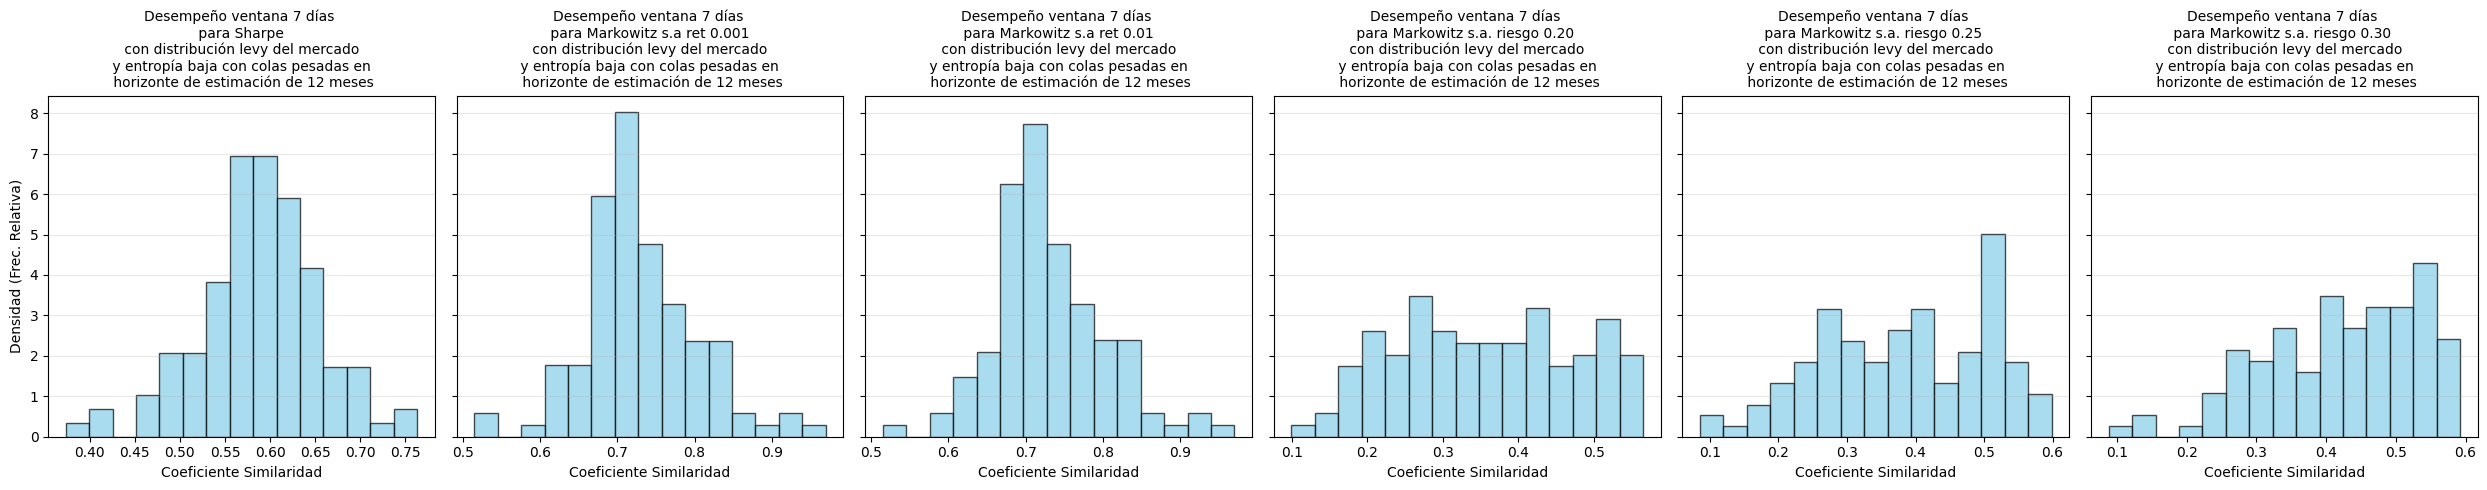

In [24]:
# 1. Configuración de la grilla (Forzada a 1 fila de 5 columnas)
modelos = df_similaridad_total_v7.columns
n_modelos = len(modelos)
n_cols = 6  # Cambiado a 5 para que entren todos en una fila
n_rows = 1  # Forzado a 1 renglón

# 2. Crear la figura y los subplots
# He aumentado el ancho (25) para que los 5 gráficos tengan espacio
fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, 5), sharey=True, sharex=False)

# 3. Bucle para generar cada histograma
for i, modelo in enumerate(modelos):
    # Si solo hay una fila, axes puede no ser una matriz, lo tratamos con cuidado
    ax = axes[i] if n_modelos > 1 else axes
    
    # Generar el histograma con densidad
    ax.hist(df_similaridad_total_v7[modelo], bins=15, color='skyblue', 
            edgecolor='black', alpha=0.7, density=True)
    
    # Configuración del título
    ax.set_title(f'Desempeño ventana 7 días \n para {modelo} \n con distribución levy del mercado \n y entropía baja con colas pesadas en \n horizonte de estimación de 12 meses' , fontsize=10)

    ax.set_xlabel('Coeficiente Similaridad')
    # Solo ponemos el label del eje Y en el primero para no saturar
    if i == 0:
        ax.set_ylabel('Densidad (Frec. Relativa)')
        
    ax.grid(axis='y', alpha=0.3)

# 4. Limpiar subplots vacíos (en caso de que haya menos de 5 modelos)
if n_modelos < n_cols:
    for j in range(i + 1, n_cols):
        fig.delaxes(axes[j])

# Ajustar espaciado
plt.tight_layout()
fig.savefig("imgs_simu/5_Ci_hist_v7_mdocp_be", dpi=300, bbox_inches='tight')

/tmp/ipykernel_18321/949606129.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(df_similaridad_total_v3.columns, rotation=90)
/tmp/ipykernel_18321/949606129.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(df_similaridad_total_v5.columns, rotation=90)
/tmp/ipykernel_18321/949606129.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(df_similaridad_total_v7.columns, rotation=90)


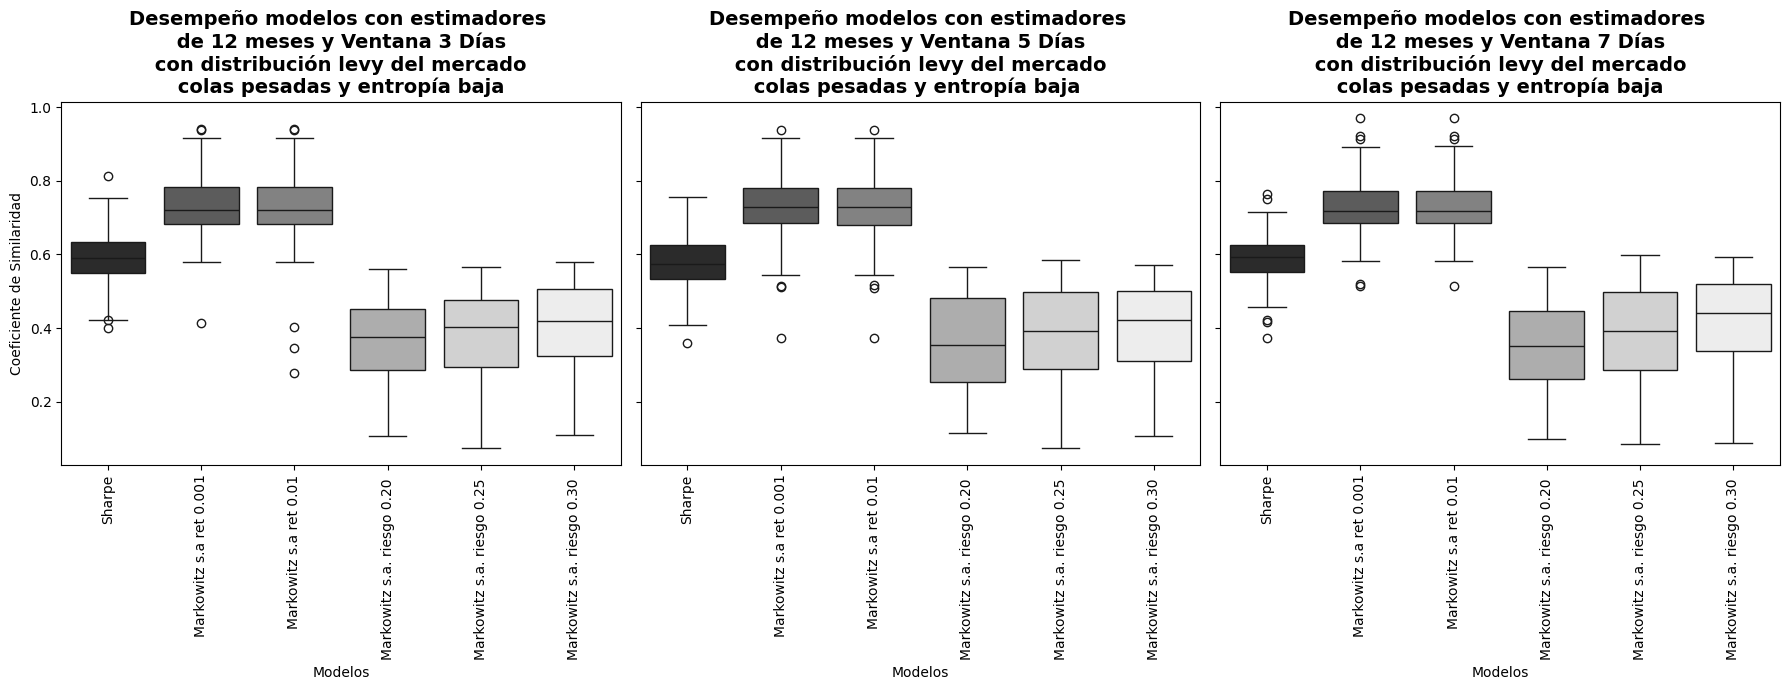

In [25]:
# 1. Configuración de la figura: 1 fila, 2 columnas
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

# 2. Gráfico 1: Ventana 3 días
sns.boxplot(
    data=df_similaridad_total_v3, 
    ax=axes[0], 
    palette="Greys_r"
)
axes[0].set_title('Desempeño modelos con estimadores \n de 12 meses y Ventana 3 Días \n con distribución levy del mercado \n colas pesadas y entropía baja ', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(df_similaridad_total_v3.columns, rotation=90)
axes[0].set_ylabel('Coeficiente de Similaridad')
axes[0].set_xlabel('Modelos')

# 3. Gráfico 2: Ventana 5 días
sns.boxplot(
    data=df_similaridad_total_v5, 
    ax=axes[1], 
    palette="Greys_r"
)
axes[1].set_title('Desempeño modelos con estimadores \n de 12 meses y Ventana 5 Días \n con distribución levy del mercado \n colas pesadas y entropía baja  ', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(df_similaridad_total_v5.columns, rotation=90)
axes[1].set_ylabel('') # Quitamos el label porque comparten eje Y
axes[1].set_xlabel('Modelos')

# 3. Gráfico 3: Ventana 5 días
sns.boxplot(
    data=df_similaridad_total_v7, 
    ax=axes[2], 
    palette="Greys_r"
)
axes[2].set_title('Desempeño modelos con estimadores \n de 12 meses y Ventana 7 Días \n con distribución levy del mercado \n colas pesadas y entropía baja ', fontsize=14, fontweight='bold')
axes[2].set_xticklabels(df_similaridad_total_v7.columns, rotation=90)
axes[2].set_ylabel('') # Quitamos el label porque comparten eje Y
axes[2].set_xlabel('Modelos')


# Ajustes finales
plt.tight_layout()
fig.savefig("imgs_simu/5_Ci_box_comp_v_mdocp_be", dpi=300, bbox_inches='tight')

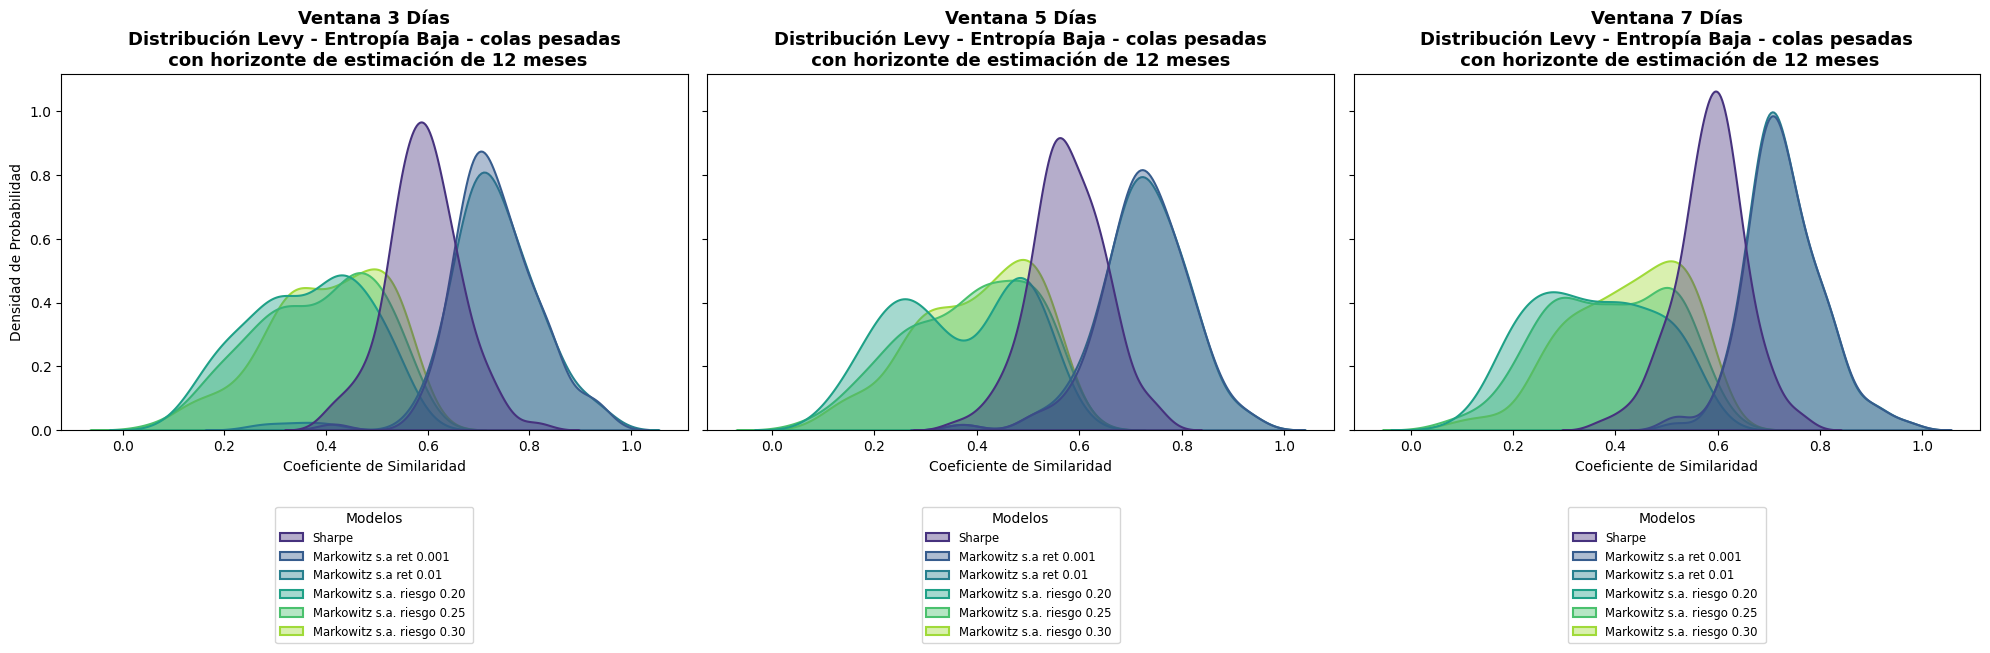

In [26]:
# 1. Configuración de la figura: 1 fila, 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)

# Lista de dataframes y sus títulos correspondientes
dfs = [df_similaridad_total_v3, df_similaridad_total_v5, df_similaridad_total_v7]
titulos = [
    'Ventana 3 Días\nDistribución Levy - Entropía Baja - colas pesadas\n con horizonte de estimación de 12 meses',
    'Ventana 5 Días\nDistribución Levy - Entropía Baja - colas pesadas\n con horizonte de estimación de 12 meses ',
    'Ventana 7 Días\nDistribución Levy - Entropía Baja - colas pesadas\n con horizonte de estimación de 12 meses'
]

# 2. Iterar sobre los ejes y los datos para generar los KDEs
for i, df in enumerate(dfs):
    # Convertimos de formato ancho a largo para que Seaborn reconozca los modelos como categorías
    df_long = df.melt(var_name='Modelo', value_name='Similaridad')
    
    sns.kdeplot(
        data=df_long,
        x="Similaridad",
        hue="Modelo",
        fill=True,
        ax=axes[i],
        palette="viridis", # Una paleta colorida ayuda a diferenciar modelos
        alpha=0.4,
        linewidth=1.5
    )
    
    axes[i].set_title(titulos[i], fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Coeficiente de Similaridad')
    
    # Solo el primer gráfico lleva etiqueta en el eje Y
    if i == 0:
        axes[i].set_ylabel('Densidad de Probabilidad')
    else:
        axes[i].set_ylabel('')

# 3. Ajustes de la leyenda para que no tape el gráfico si hay muchos modelos
for ax in axes:
    sns.move_legend(ax,  fontsize='small', title="Modelos",  loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Ajustes finales
plt.tight_layout()
fig.savefig("imgs_simu/5_Ci_kde_comp_v_mdocp_be", dpi=300, bbox_inches='tight')

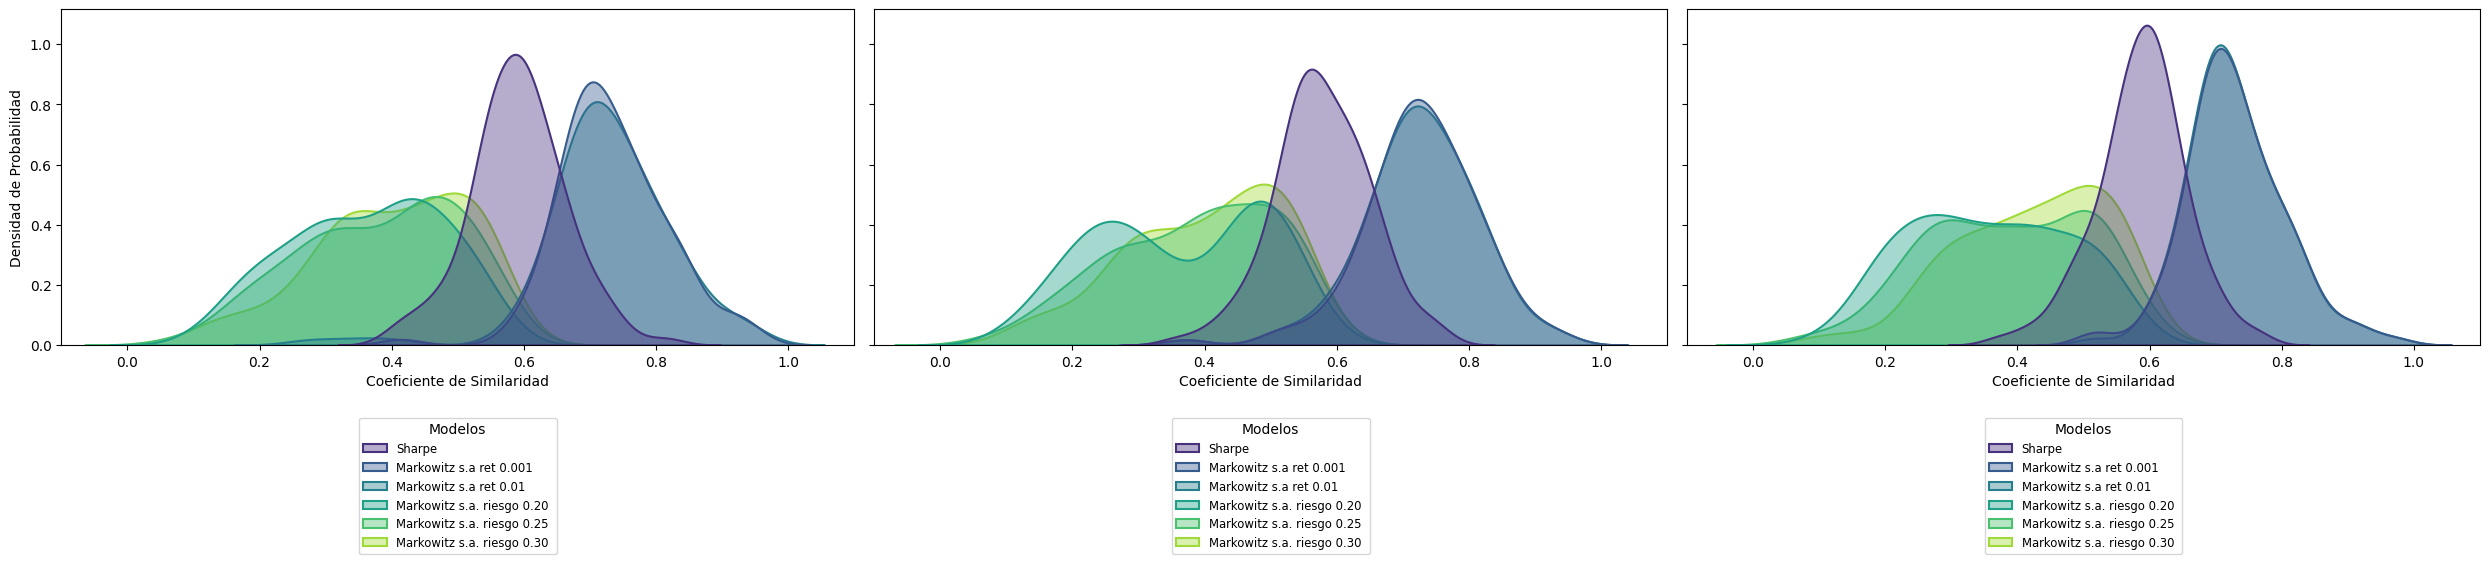

In [27]:
# 1. Configuración de la figura: 1 fila, 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(25, 6), sharey=True)

# Lista de dataframes y sus títulos correspondientes
dfs = [df_similaridad_total_v3, df_similaridad_total_v5, df_similaridad_total_v7]
titulos = [
    '',
    '',
    ''
]

# 2. Iterar sobre los ejes y los datos para generar los KDEs
for i, df in enumerate(dfs):
    # Convertimos de formato ancho a largo para que Seaborn reconozca los modelos como categorías
    df_long = df.melt(var_name='Modelo', value_name='Similaridad')
    
    sns.kdeplot(
        data=df_long,
        x="Similaridad",
        hue="Modelo",
        fill=True,
        ax=axes[i],
        palette="viridis", # Una paleta colorida ayuda a diferenciar modelos
        alpha=0.4,
        linewidth=1.5
    )
    # --- AJUSTE DE EJES ---
    axes[i].set_xlim(-0.10, 1.1) # Fija el rango del eje X
    # ----------------------
    
    
    axes[i].set_title(titulos[i], fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Coeficiente de Similaridad')
    
    # Solo el primer gráfico lleva etiqueta en el eje Y
    if i == 0:
        axes[i].set_ylabel('Densidad de Probabilidad')
    else:
        axes[i].set_ylabel('')

# 3. Ajustes de la leyenda para que no tape el gráfico si hay muchos modelos
for ax in axes:
    sns.move_legend(ax,  fontsize='small', title="Modelos",  loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Ajustes finales
plt.tight_layout()
fig.savefig("imgs_simu/5si_Ci_kde_comp_v_mdocp_be", dpi=300, bbox_inches='tight')

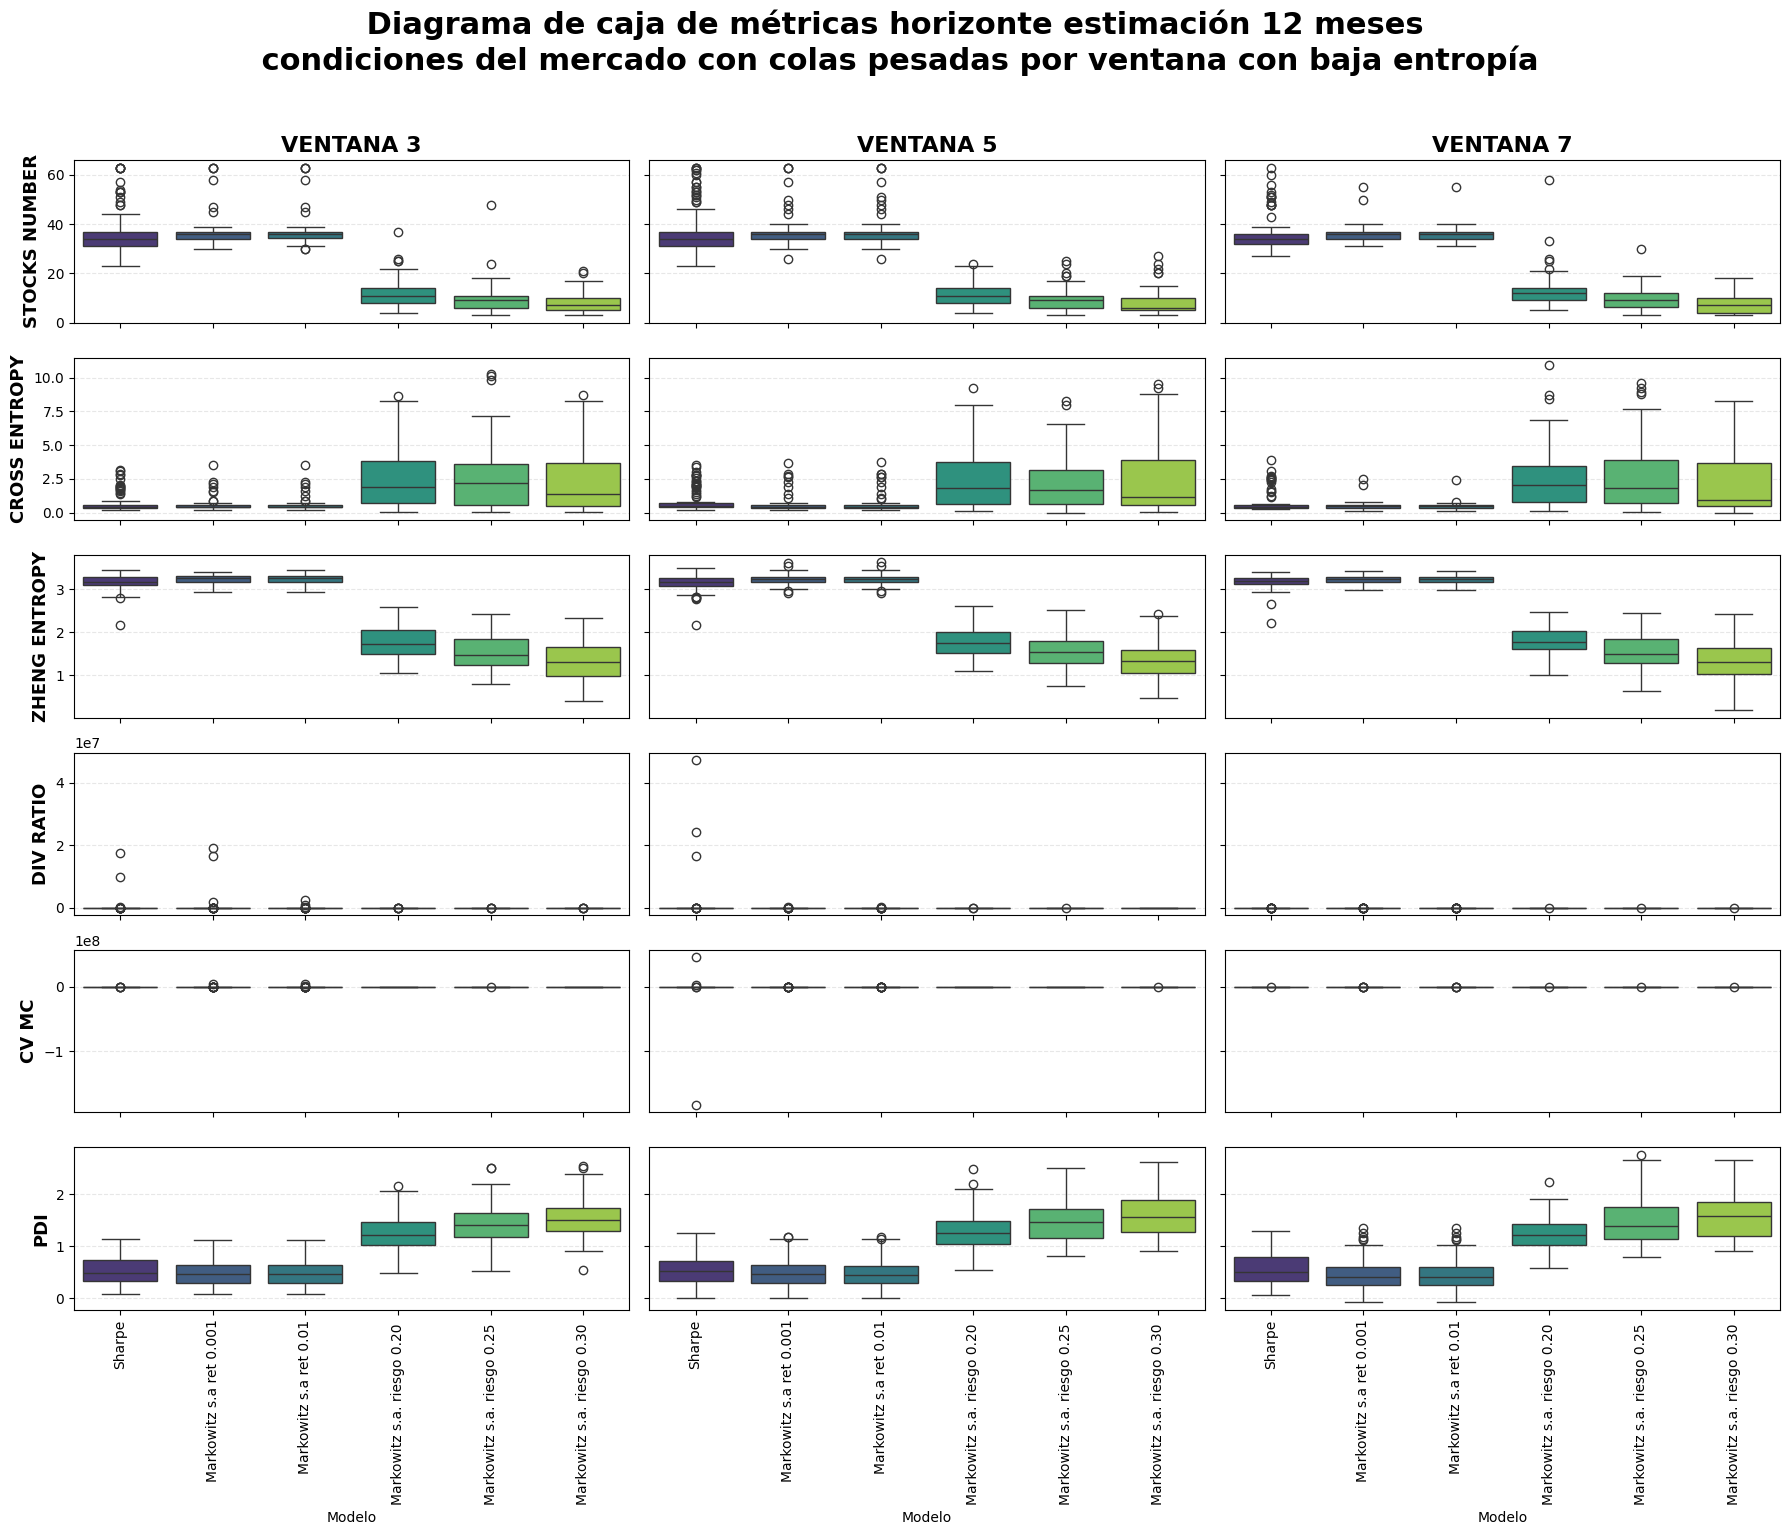

In [28]:
# Silenciamos advertencias para una salida limpia
warnings.filterwarnings('ignore', category=FutureWarning)

# 1. Configuración de parámetros y métricas
metricas = ['stocks_number', 'Cross_Entropy', 'Zheng_Entropy', 'Div_Ratio', 'CV_MC', 'PDI']
ventanas_deseadas = [3, 5, 7] 
ventanas_presentes = [v for v in ventanas_deseadas if v in df_metricas_limpio.index.get_level_values('Ventana')]

# 2. Crear la grilla con SHAREY por FILA (métrica) y SHAREX global
# Usamos sharey='row' para que la escala sea comparable entre ventanas para una misma métrica
fig, axes = plt.subplots(nrows=len(metricas), ncols=len(ventanas_presentes), 
                         figsize=(6 * len(ventanas_presentes), 2.5 * len(metricas)), 
                         sharex=True, sharey='row')

fig.suptitle(' Diagrama de caja de métricas horizonte estimación 12 meses \n condiciones del mercado con colas pesadas por ventana con baja entropía', fontsize=22, fontweight='bold', y=1.02)

# 3. Bucle doble: Métrica (Fila) e itera por Ventana (Columna)
for i, col in enumerate(metricas):
    for j, ventana in enumerate(ventanas_presentes):
        ax = axes[i, j]
        
        # Filtramos la ventana actual del DataFrame original
        df_ventana = df_metricas_limpio.xs(ventana, level='Ventana').reset_index()
        
        # Graficamos con corrección de FutureWarning
        sns.boxplot(
            data=df_ventana, 
            x='Modelo_Opt', 
            y=col, 
            ax=ax, 
            palette='viridis', 
            hue='Modelo_Opt',
            legend=False
        )
        
        # Estética de Encabezados (solo primera fila)
        if i == 0:
            ax.set_title(f'VENTANA {ventana}', fontsize=16, fontweight='bold')
        
        # Estética de Etiquetas (solo primera columna para evitar redundancia con sharey)
        if j == 0:
            ax.set_ylabel(col.replace('_', ' ').upper(), fontsize=13, fontweight='bold')
        else:
            ax.set_ylabel('')
            
        # Etiquetas de modelos (solo última fila)
        if i == len(metricas) - 1:
            ax.tick_params(axis='x', rotation=90)
            ax.set_xlabel('Modelo')
        else:
            ax.set_xlabel('')

        ax.grid(True, axis='y', linestyle='--', alpha=0.3)

# 4. Ajuste final
plt.tight_layout()
fig.savefig("imgs_simu/5_Criteria_box_comp_v_mdocp_be", dpi=300, bbox_inches='tight')

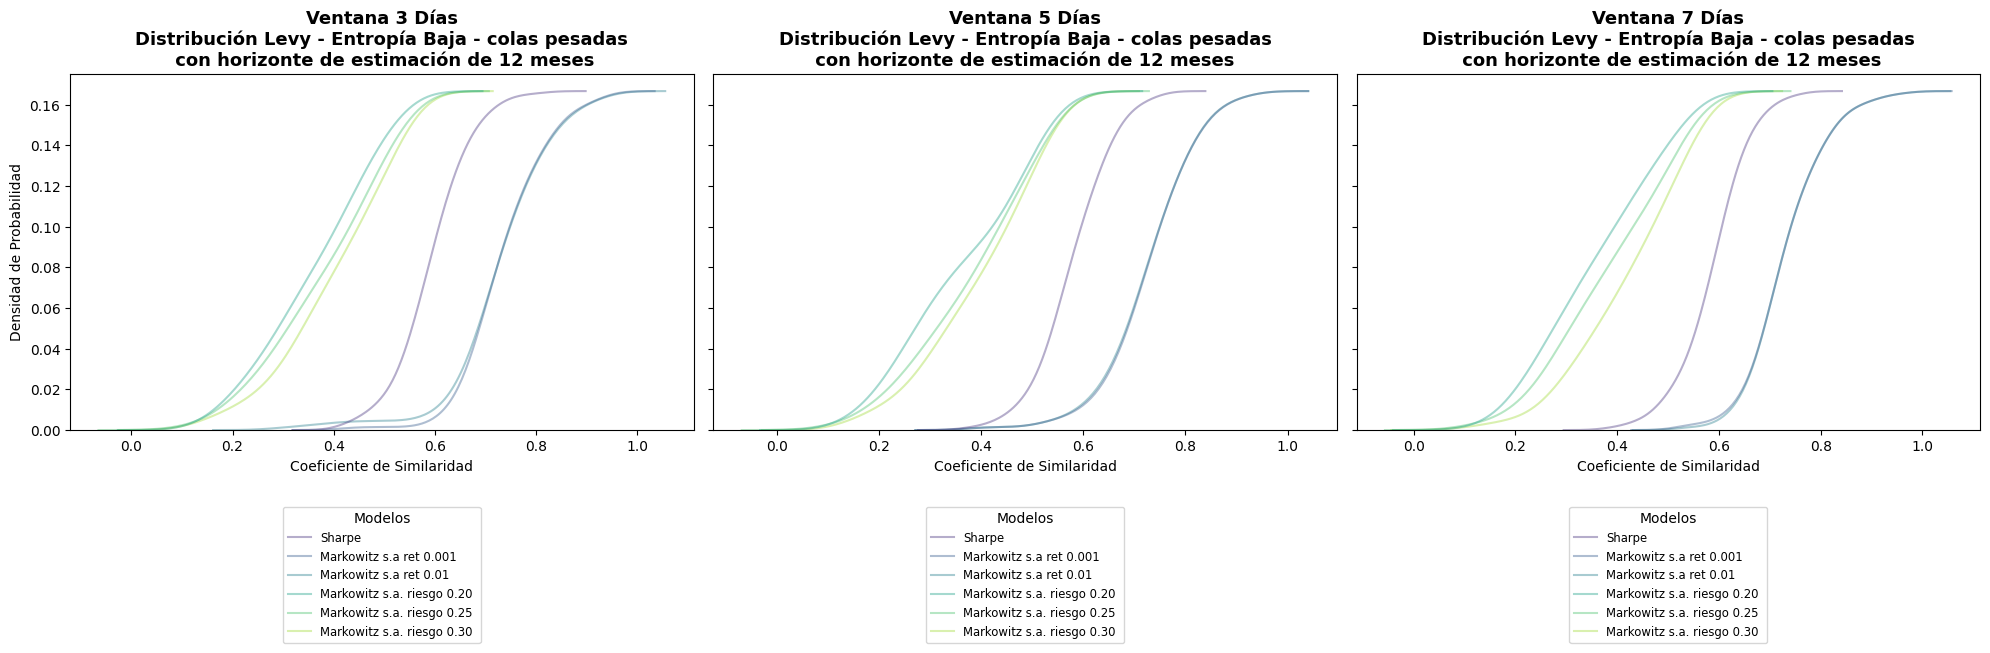

In [29]:
# 1. Configuración de la figura: 1 fila, 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)

# Lista de dataframes y sus títulos correspondientes
dfs = [df_similaridad_total_v3, df_similaridad_total_v5, df_similaridad_total_v7]
titulos = [
    'Ventana 3 Días\nDistribución Levy - Entropía Baja - colas pesadas\n con horizonte de estimación de 12 meses',
    'Ventana 5 Días\nDistribución Levy - Entropía Baja - colas pesadas\n con horizonte de estimación de 12 meses ',
    'Ventana 7 Días\nDistribución Levy - Entropía Baja - colas pesadas\n con horizonte de estimación de 12 meses'
]

# 2. Iterar sobre los ejes y los datos para generar los KDEs
for i, df in enumerate(dfs):
    # Convertimos de formato ancho a largo para que Seaborn reconozca los modelos como categorías
    df_long = df.melt(var_name='Modelo', value_name='Similaridad')
    
    sns.kdeplot(
        data=df_long,
        x="Similaridad",
        hue="Modelo",
        cumulative=True,
        fill=False,
        ax=axes[i],
        palette="viridis", # Una paleta colorida ayuda a diferenciar modelos
        alpha=0.4,
        linewidth=1.5
    )
    
    axes[i].set_title(titulos[i], fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Coeficiente de Similaridad')
    
    # Solo el primer gráfico lleva etiqueta en el eje Y
    if i == 0:
        axes[i].set_ylabel('Densidad de Probabilidad')
    else:
        axes[i].set_ylabel('')

# 3. Ajustes de la leyenda para que no tape el gráfico si hay muchos modelos
for ax in axes:
    sns.move_legend(ax,  fontsize='small', title="Modelos",  loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Ajustes finales
plt.tight_layout()
fig.savefig("imgs_simu/5_Ci_ojiva_comp_v_mdocp_be", dpi=300, bbox_inches='tight')

In [30]:
v7similar_describe = df_similaridad_total_v7.describe()
kurtosis_values = df_similaridad_total_v7.kurt()
v7similar_describe.loc["kurt"] = kurtosis_values
skew_values = df_similaridad_total_v7.skew()
v7similar_describe.loc["skew"] = skew_values
v7similar_describe.to_csv("dfdescribe_results/5_v7similar_describe_mdocp_be", index=True, sep=',', encoding='utf-8')
v7similar_describe

,Sharpe,Markowitz s.a ret 0.001,Markowitz s.a ret 0.01,Markowitz s.a. riesgo 0.20,Markowitz s.a. riesgo 0.25,Markowitz s.a. riesgo 0.30
count,111.000000,111.000000,111.000000,111.000000,111.000000,111.000000
mean,0.586694,0.729065,0.730236,0.356098,0.385381,0.422515
std,0.067279,0.075003,0.072792,0.119575,0.121356,0.112715
min,0.373511,0.515162,0.515513,0.099463,0.085529,0.087952
25%,0.553458,0.685601,0.685619,0.262524,0.287086,0.337910
50%,0.593374,0.718037,0.718221,0.351563,0.391418,0.440742
75%,0.624583,0.773314,0.773503,0.447808,0.499406,0.520689
max,0.763067,0.969675,0.969675,0.565143,0.598570,0.592230
kurt,0.777284,1.153181,1.049749,-1.085093,-0.851734,-0.301320
skew,-0.299569,0.300519,0.486995,0.020480,-0.241829,-0.548634


In [31]:
v5similar_describe = df_similaridad_total_v5.describe()
kurtosis_values = df_similaridad_total_v5.kurt()
v5similar_describe.loc["kurt"] = kurtosis_values
skew_values = df_similaridad_total_v5.skew()
v5similar_describe.loc["skew"] = skew_values
v5similar_describe.to_csv("dfdescribe_results/5_v5similar_describe_mdocp_be", index=True, sep=',', encoding='utf-8')
v5similar_describe

,Sharpe,Markowitz s.a ret 0.001,Markowitz s.a ret 0.01,Markowitz s.a. riesgo 0.20,Markowitz s.a. riesgo 0.25,Markowitz s.a. riesgo 0.30
count,111.000000,111.000000,111.000000,111.000000,111.000000,111.000000
mean,0.577339,0.726973,0.725552,0.362755,0.384730,0.399179
std,0.071762,0.086653,0.087327,0.128090,0.122809,0.116645
min,0.359914,0.372256,0.372555,0.116186,0.074087,0.106642
25%,0.534443,0.685109,0.680565,0.253696,0.289038,0.312347
50%,0.573217,0.728216,0.728216,0.353421,0.392486,0.421163
75%,0.624660,0.781192,0.781138,0.482042,0.498255,0.501234
max,0.755037,0.938833,0.938833,0.565294,0.584660,0.572365
kurt,0.364569,2.130547,1.934999,-1.337869,-0.745569,-0.600957
skew,-0.118254,-0.629809,-0.603655,-0.138498,-0.425465,-0.522361


In [32]:
v3similar_describe = df_similaridad_total_v3.describe()
kurtosis_values = df_similaridad_total_v3.kurt()
v3similar_describe.loc["kurt"] = kurtosis_values
skew_values = df_similaridad_total_v3.skew()
v3similar_describe.loc["skew"] = skew_values
v3similar_describe.to_csv("dfdescribe_results/5_v3similar_describe_mdocp_be", index=True, sep=',', encoding='utf-8')
v3similar_describe

,Sharpe,Markowitz s.a ret 0.001,Markowitz s.a ret 0.01,Markowitz s.a. riesgo 0.20,Markowitz s.a. riesgo 0.25,Markowitz s.a. riesgo 0.30
count,111.000000,111.000000,111.000000,111.000000,111.000000,111.000000
mean,0.590900,0.733661,0.726764,0.361376,0.381574,0.401777
std,0.071502,0.081284,0.099107,0.115088,0.120407,0.115665
min,0.401829,0.414275,0.277563,0.107939,0.075924,0.109944
25%,0.549532,0.682479,0.681994,0.287391,0.293737,0.324816
50%,0.589620,0.721787,0.721301,0.375912,0.401950,0.418608
75%,0.634831,0.782938,0.782938,0.451752,0.475752,0.506393
max,0.814304,0.939266,0.939266,0.559432,0.565723,0.578953
kurt,0.650720,1.652023,5.370016,-0.947941,-0.804576,-0.426841
skew,0.041466,0.003299,-1.277348,-0.207192,-0.369598,-0.532121
